In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.linear_model import LinearRegression

In [7]:
sales = pd.read_csv("sales_data.csv")

sales.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [6]:
sales.describe()

,Quantity,Price,Total_Sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


In [21]:
print("Mean:", sales["Total_Sales"].mean())
print("Median:", sales["Total_Sales"].median())
print("Mode:", sales["Total_Sales"].mode()[0])
print("Standard Deviation:", sales["Total_Sales"].std())

Mean: 123650.48
Median: 97955.5
Mode: 6540
Standard Deviation: 100161.08527499212


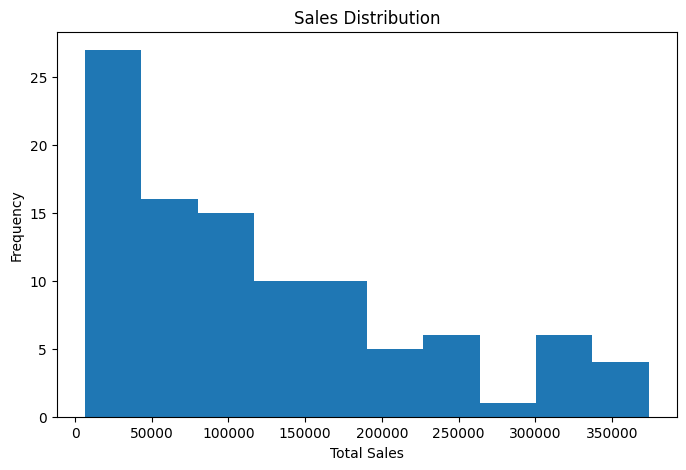

In [20]:
plt.figure(figsize=(8,5))
plt.hist(sales["Total_Sales"], bins=10)
plt.title("Sales Distribution")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()

In [19]:
sales[["Quantity","Price","Total_Sales"]].corr()

,Quantity,Price,Total_Sales
Quantity,1.000000,0.008014,0.688107
Price,0.008014,1.000000,0.646131
Total_Sales,0.688107,0.646131,1.000000


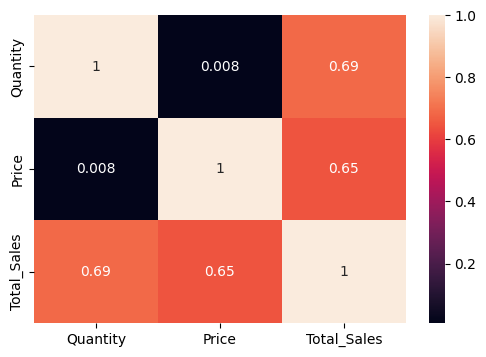

In [18]:
plt.figure(figsize=(6,4))

sns.heatmap(
    sales[["Quantity","Price","Total_Sales"]].corr(),
    annot=True
)

plt.show()

In [16]:
east = sales[sales["Region"]=="East"]["Total_Sales"]
west = sales[sales["Region"]=="West"]["Total_Sales"]

t_stat, p_value = stats.ttest_ind(east, west)

print("T Statistic:", t_stat)
print("P Value:", p_value)

T Statistic: 2.0202108796829767
P Value: 0.049619032636626016


In [15]:
north = sales[sales["Region"]=="North"]["Total_Sales"]
south = sales[sales["Region"]=="South"]["Total_Sales"]

t_stat, p_value = stats.ttest_ind(north, south)

print("T Statistic:", t_stat)
print("P Value:", p_value)

T Statistic: 0.1303316283399723
P Value: 0.8967974805172009


In [14]:
east = sales[sales["Region"]=="East"]["Total_Sales"]
north = sales[sales["Region"]=="North"]["Total_Sales"]

t_stat, p_value = stats.ttest_ind(east, north)

print("T Statistic:", t_stat)
print("P Value:", p_value)

T Statistic: -0.35710677600784724
P Value: 0.7226811638407538


In [22]:
mean = sales["Total_Sales"].mean()

confidence_interval = stats.t.interval(
    0.95,
    len(sales)-1,
    loc=mean,
    scale=stats.sem(sales["Total_Sales"])
)

print(confidence_interval)

(np.float64(103776.3476708068), np.float64(143524.6123291932))
